# Task 1 : Configuration

Dataset: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia/data

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

100%|██████████| 2.29G/2.29G [07:52<00:00, 5.21MB/s] 

Extracting files...


Path to dataset files: C:\Users\Vaibhav Tandon\.cache\kagglehub\datasets\paultimothymooney\chest-xray-pneumonia\versions\2


In [3]:
!pip install timm

   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ------------- -------------------------- 0.8/2.4 MB 5.6 MB/s eta 0:00:01
   ------------- -------------------------- 0.8/2.4 MB 5.6 MB/s eta 0:00:01
   ------------- -------------------------- 0.8/2.4 MB 5.6 MB/s eta 0:00:01
   ------------- -------------------------- 0.8/2.4 MB 5.6 MB/s eta 0:00:01
   ------------- -------------------------- 0.8/2.4 MB 5.6 MB/s eta 0:00:01
   ------------- -------------------------- 0.8/2.4 MB 5.6 MB/s eta 0:00:01
   ------------- -------------------------- 0.8/2.4 MB 5.6 MB/s eta 0:00:01
   ---------------------- ----------------- 1.3/2.4 MB 664.5 kB/s eta 0:00:02
   ---------------------------------------- 2.4/2.4 MB 1.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   -------------------------- ------------- 1.0/1.6 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 5.2 MB/s eta 0:00:00


In [5]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import timm
import os
from tqdm.notebook import tqdm

from helper import view_classify, show_image, show_grid, accuracy

In [24]:
class CFG:

    epochs = 20                                        # No. of epochs of training the model
    lr = 0.001                                         # Learning rate
    batch_size = 16                                    # Batch Size For Dataset

    model_name = 'tf_efficientnet_b4_ns'               # Model name (We are going to import model from timm)
    img_size = 224

    # Going to be use for loading dataset
    DATA_DIR = "archive\chest_xray\chest_xray"  # Data Directory
    TEST = 'test'                                      # Test folder name in data directory
    TRAIN = 'train'                                    # Train folder name in data directory
    VAL ='val'                                         # Valid folder name in data directory

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("On which device we are on : {}".format(device))

On which device we are on : cpu


<>:11: SyntaxWarning: invalid escape sequence '\c'
<>:11: SyntaxWarning: invalid escape sequence '\c'
C:\Users\Vaibhav Tandon\AppData\Local\Temp\ipykernel_23872\3307551977.py:11: SyntaxWarning: invalid escape sequence '\c'
  DATA_DIR = "archive\chest_xray\chest_xray"  # Data Directory


# Task 2 : Image Transformation and Load Dataset

In [25]:
from torchvision import transforms as T, datasets

In [26]:
train_transform = T.Compose([

    T.Resize(size = (CFG.img_size,CFG.img_size)),
    T.RandomRotation(degrees = (-20,+20)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])
])

valid_transform = T.Compose([

    T.Resize(size = (CFG.img_size,CFG.img_size)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])
])

test_transform = T.Compose([

    T.Resize(size = (CFG.img_size,CFG.img_size)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225])
])

In [27]:
train_path = os.path.join(CFG.DATA_DIR, CFG.TRAIN)
valid_path = os.path.join(CFG.DATA_DIR, CFG.VAL)
test_path = os.path.join(CFG.DATA_DIR, CFG.TEST)

trainset = datasets.ImageFolder(train_path,transform = train_transform)
validset = datasets.ImageFolder(valid_path,transform = valid_transform)
testset = datasets.ImageFolder(test_path,transform = test_transform)

In [28]:
print("Trainset Size : {}".format(len(trainset)))
print("Validset Size : {}".format(len(validset)))
print("Testset Size : {}".format(len(testset)))

Trainset Size : 5216
Validset Size : 16
Testset Size : 624


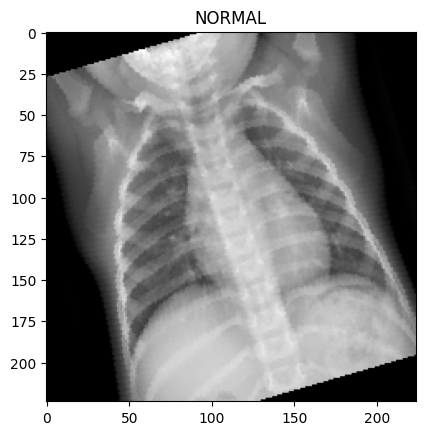

In [29]:
image, label = trainset[2]

class_names = ['NORMAL','PNEUMONIA']

show_image(image,class_names[label])

# Load Dataset into Batches

In [30]:
from torch.utils.data import DataLoader
from torchvision.utils import make_grid

In [31]:
trainloader = DataLoader(trainset, batch_size = CFG.batch_size , shuffle = True)
validloader = DataLoader(validset, batch_size = CFG.batch_size , shuffle = True)
testloader = DataLoader(testset, batch_size = CFG.batch_size , shuffle = True)

In [32]:
print("No. of batches in trainloader : {}".format(len(trainloader)))
print("No. of Total examples : {}".format(len(trainloader.dataset)))

No. of batches in trainloader : 326
No. of Total examples : 5216


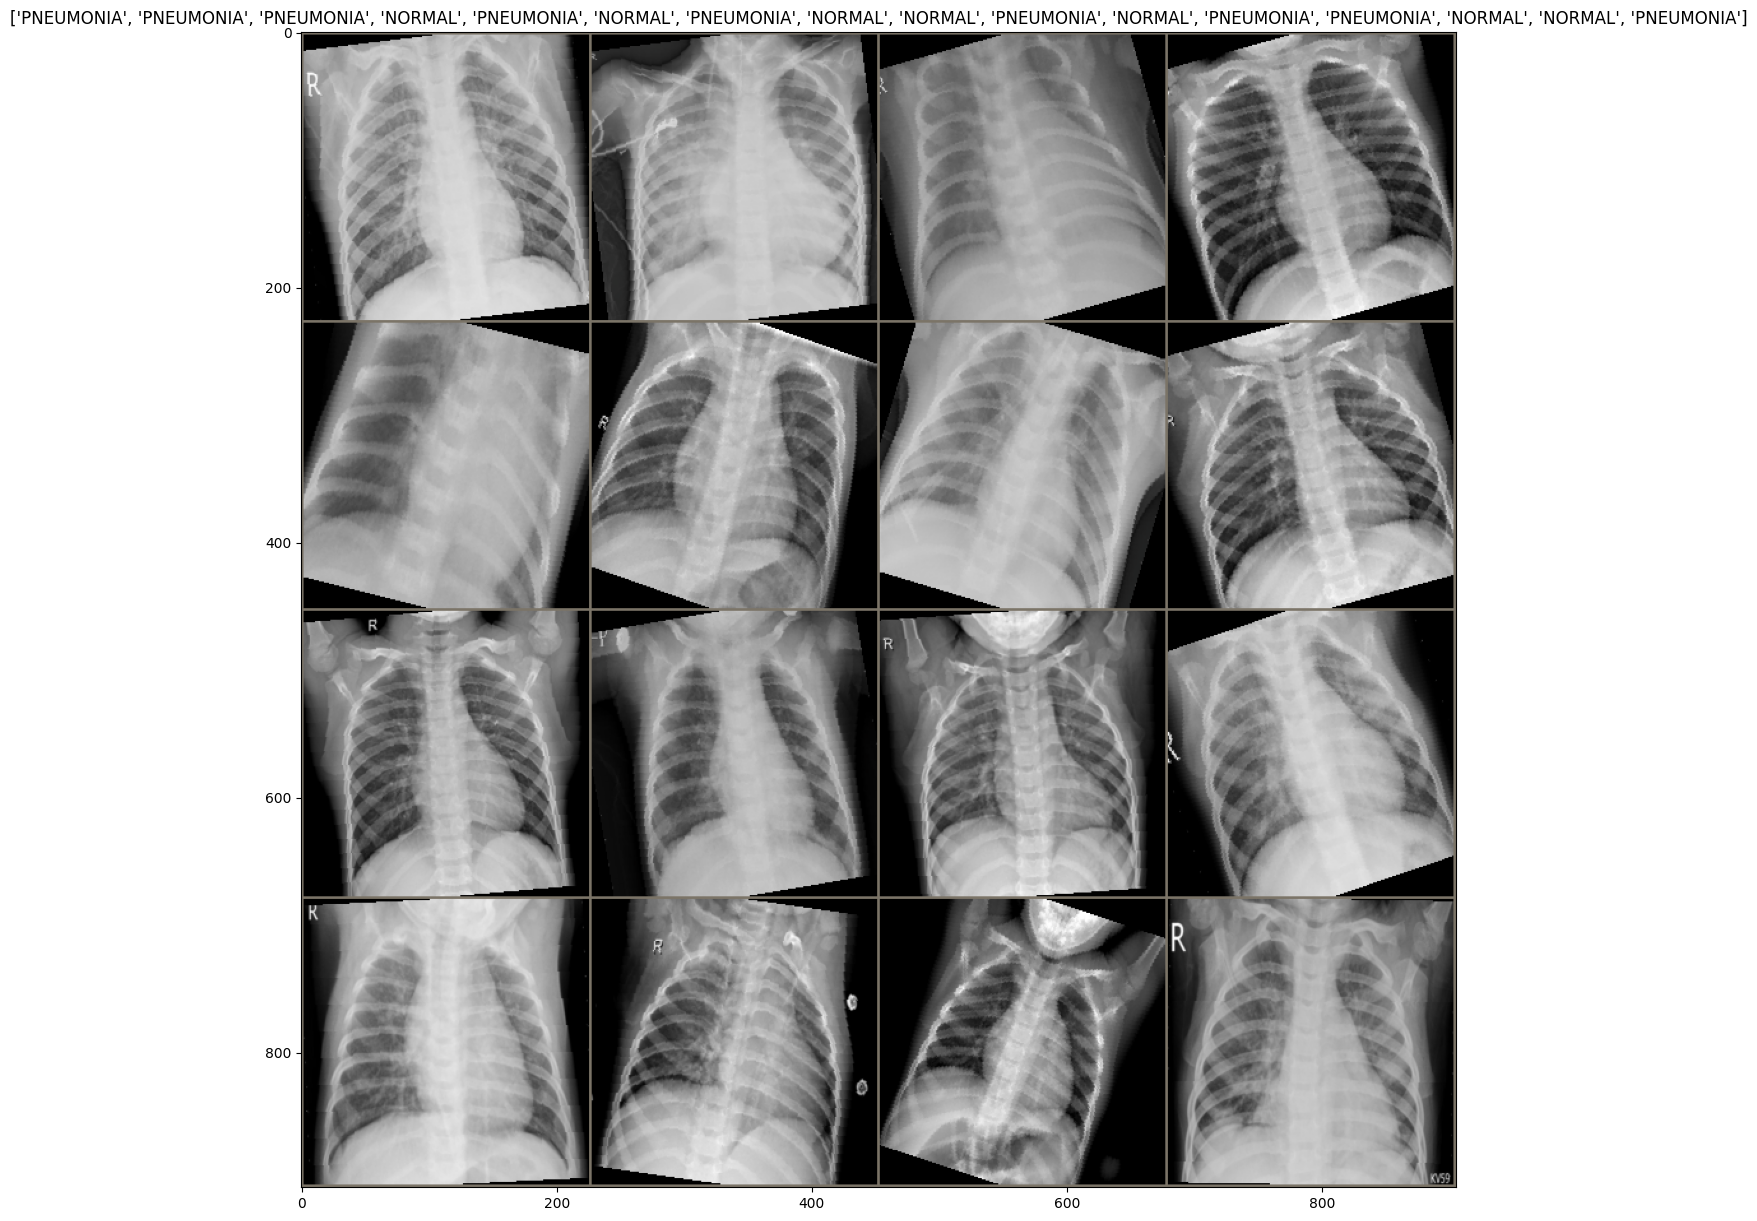

In [34]:
dataiter = iter(trainloader)
images,labels = next(dataiter)

out = make_grid(images,nrow=4)

show_grid(out, title=[class_names[x] for x in labels])

# Fine Tuning EfficientNet Model

In [36]:
from torch import nn
import torch.nn.functional as F

model = timm.create_model(CFG.model_name,pretrained = True)

for param in model.parameters():
    param.requires_grad = False

model.classifier = nn.Sequential(

        nn.Linear(in_features = 1792, out_features = 625),
        nn.ReLU(),
        nn.Dropout(p = 0.3),
        nn.Linear(in_features = 625, out_features = 256),
        nn.ReLU(),
        nn.Linear(in_features = 256, out_features = 2)

)

model.to(device)

EfficientNet(
  (conv_stem): Conv2dSame(3, 48, kernel_size=(3, 3), stride=(2, 2), bias=False)
  (bn1): BatchNormAct2d(
    48, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
        (bn1): BatchNormAct2d(
          48, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(48, 12, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(12, 48, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(48, 24, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2): BatchNo

# Build a Simple Trainer

In [37]:
class PneumoniaTrainer():

    def __init__(self,criterion = None,optimizer = None,schedular = None):

        self.criterion = criterion
        self.optimizer = optimizer
        self.schedular = schedular

    def train_batch_loop(self,model,trainloader):

        train_loss = 0.0
        train_acc = 0.0

        for images,labels in tqdm(trainloader):

            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = self.criterion(logits,labels)

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            train_loss += loss.item()
            train_acc += accuracy(logits,labels)

        return train_loss / len(trainloader), train_acc / len(trainloader)


    def valid_batch_loop(self,model,validloader):

        valid_loss = 0.0
        valid_acc = 0.0

        for images,labels in tqdm(validloader):

            images = images.to(device)
            labels = labels.to(device)

            logits = model(images)
            loss = self.criterion(logits,labels)

            valid_loss += loss.item()
            valid_acc += accuracy(logits,labels)

        return valid_loss / len(validloader), valid_acc / len(validloader)


    def fit(self,model,trainloader,validloader,epochs):

        valid_min_loss = np.Inf

        for i in range(epochs):

            model.train()
            avg_train_loss, avg_train_acc = self.train_batch_loop(model,trainloader)

            model.eval()
            avg_valid_loss, avg_valid_acc = self.valid_batch_loop(model,validloader)

            if avg_valid_loss <= valid_min_loss :
                print("Valid_loss decreased {} --> {}".format(valid_min_loss,avg_valid_loss))
                torch.save(model.state_dict(),'PneumoniaModel.pt')
                valid_min_loss = avg_valid_loss


            print("Epoch : {} Train Loss : {:.6f} Train Acc : {:.6f}".format(i+1, avg_train_loss, avg_train_acc))
            print("Epoch : {} Valid Loss : {:.6f} Valid Acc : {:.6f}".format(i+1, avg_valid_loss, avg_valid_acc))

# Training Model

In [38]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr = CFG.lr)

trainer = PneumoniaTrainer(criterion,optimizer)
trainer.fit(model,trainloader,validloader,epochs = CFG.epochs)

  0%|          | 0/326 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Valid_loss decreased inf --> 0.8120888471603394
Epoch : 1 Train Loss : 0.250572 Train Acc : 0.894939
Epoch : 1 Valid Loss : 0.812089 Valid Acc : 0.500000


  0%|          | 0/326 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

Epoch : 19 Train Loss : 0.145502 Train Acc : 0.942485
Epoch : 19 Valid Loss : 0.470567 Valid Acc : 0.687500


  0%|          | 0/326 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

Epoch : 20 Train Loss : 0.141856 Train Acc : 0.944977
Epoch : 20 Valid Loss : 0.561500 Valid Acc : 0.750000


# Plot Results

In [39]:
model.load_state_dict(torch.load('PneumoniaModel.pt'))
model.eval()

avg_test_loss, avg_test_acc = trainer.valid_batch_loop(model,testloader)


print("Test Loss : {}".format(avg_test_loss))
print("Test Acc : {}".format(avg_test_acc))

C:\Users\Vaibhav Tandon\AppData\Local\Temp\ipykernel_23872\2911519778.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('PneumoniaModel.pt

  0%|          | 0/39 [00:00<?, ?it/s]

Test Loss : 0.30363011904633963
Test Acc : 0.8846153616905212


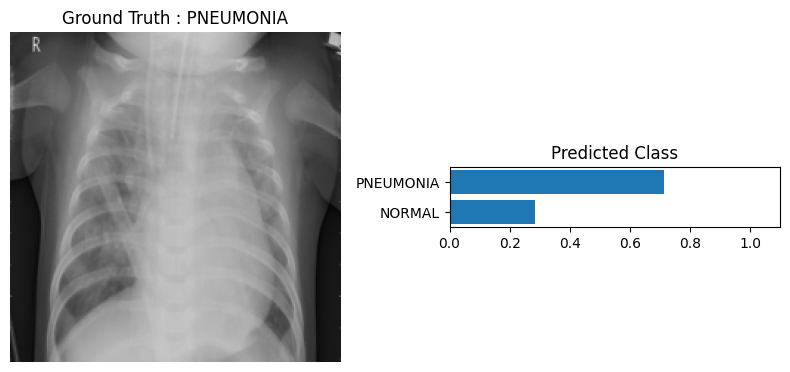

In [45]:
import torch.nn.functional as F

image,label = testset[323]

ps = model(image.to(device).unsqueeze(0))
ps = F.softmax(ps,dim = 1)

view_classify(image,ps,label)